In [2]:
import fiesta
import glob
#from fiesta.surrogates import download_recommended_surrogates
#download_recommended_surrogates()

from survey_sim import DetectionCriteria

from survey_sim import FixedBu2026KilonovaPopulation, SimulationPipeline, load_ztf_survey
from survey_sim import Bu2026KilonovaPopulation
from survey_sim.fiesta_model import FiestaKNModel
from contextlib import redirect_stdout
import io
import math
# from fiesta.surrogates import download_recommended_surrogates; download_recommended_surrogates()

import numpy as np

import matplotlib.pyplot as plt

from survey_sim.fiesta_model import FiestaKNModel

from survey_sim import (
    FixedBu2026KilonovaPopulation,
    DetectionCriteria,
    SimulationPipeline,
    load_ztf_survey,
)

from survey_sim.serialization import save_result, load_result

/home/tbarna/anaconda3/envs/surveysim_dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
results = [load_result(file) for file in glob.glob("results/marathon/*.json")]
results_10M = [load_result(file) for file in glob.glob("results/ztf_10M*")]

In [4]:
results[0].rate_summaries[0].upper_limit(0.20)

RateUpperLimit(type=Kilonova, N=0, CL=20%, R_upper=1.082e2 Gpc^-3/yr, N_upper=0.223, VT_eff=2.063e-3 Gpc^3 yr)

In [44]:
# display(dir(results[0].rate_summaries[0]))
# display(dir(results[0].rate_summaries[0].upper_limit(0.20)))
display(results[0].rate_summaries[0].upper_limit(0.90).rate_upper)
display(results[1].rate_summaries[0].volumetric_rate)

np.float64(1116.2322424541426)

1000.0

In [36]:
# Extract upper limits at 20% confidence level from all results
upper_limits = [[result.rate_summaries[0].upper_limit(percentile).rate_upper for percentile in np.linspace(0, 1, 100)] for result in results]
upper_limits_10M = [[result.rate_summaries[0].upper_limit(percentile).rate_upper for percentile in np.linspace(0, 1, 100)] for result in results_10M]

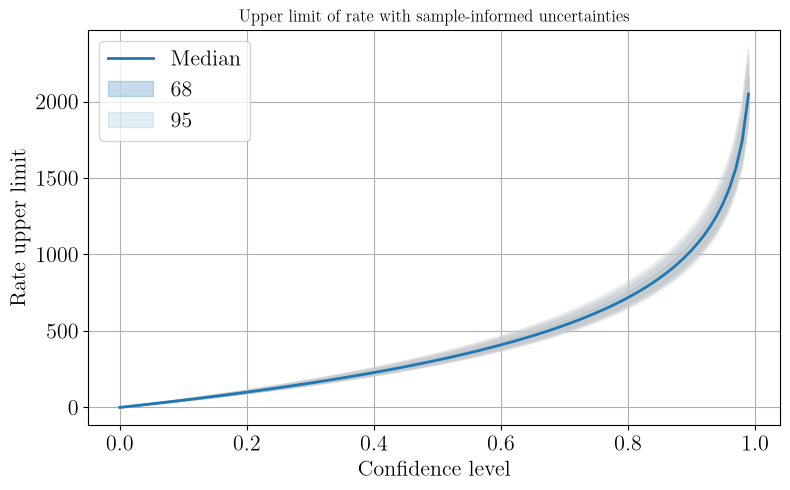

In [38]:
ul = np.asarray(upper_limits, dtype=float)
ul[~np.isfinite(ul)] = np.nan

confidence = np.linspace(0, 1, ul.shape[1])

q16 = np.nanpercentile(ul, 16, axis=0)
q50 = np.nanpercentile(ul, 50, axis=0)
q84 = np.nanpercentile(ul, 84, axis=0)
q025 = np.nanpercentile(ul, 2.5, axis=0)
q975 = np.nanpercentile(ul, 97.5, axis=0)

plt.figure(figsize=(8, 5))

for row in ul:
    plt.plot(confidence, row, color="0.8", alpha=0.25, lw=1)

plt.plot(confidence, q50, color="C0", lw=2, label="Median")
plt.fill_between(confidence, q16, q84, color="C0", alpha=0.25, label="68% interval")
plt.fill_between(confidence, q025, q975, color="C0", alpha=0.12, label="95% interval")

plt.xlabel("Confidence level")
plt.ylabel("Rate upper limit")
plt.title("Upper limit of rate with sample-informed uncertainties")
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

/tmp/ipykernel_15890/2900128633.py:22: RuntimeWarning: invalid value encountered in divide
  percent_residual = 100 * residual / q50_1m


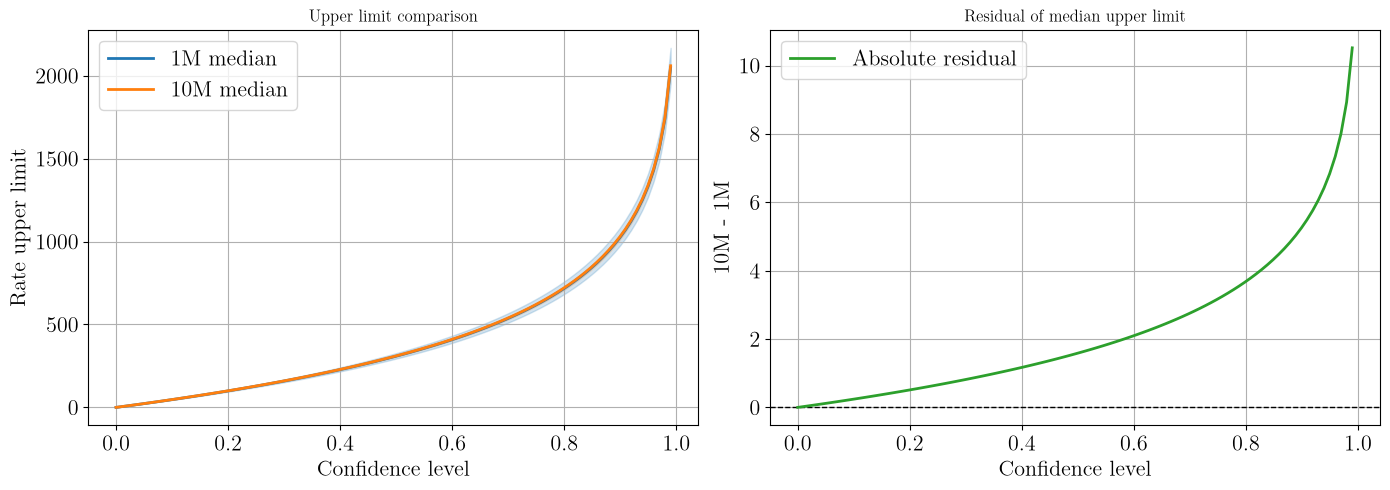

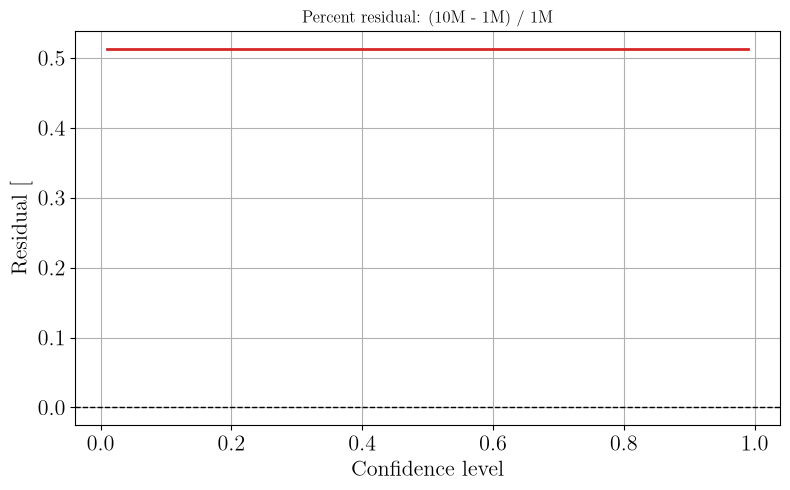

In [39]:
ul_1m = np.asarray(upper_limits, dtype=float)
ul_10m = np.asarray(upper_limits_10M, dtype=float)

ul_1m[~np.isfinite(ul_1m)] = np.nan
ul_10m[~np.isfinite(ul_10m)] = np.nan

confidence = np.linspace(0, 1, min(ul_1m.shape[1], ul_10m.shape[1]))

# Truncate to common confidence grid if needed
ul_1m = ul_1m[:, : len(confidence)]
ul_10m = ul_10m[:, : len(confidence)]

q50_1m = np.nanpercentile(ul_1m, 50, axis=0)
q16_1m = np.nanpercentile(ul_1m, 16, axis=0)
q84_1m = np.nanpercentile(ul_1m, 84, axis=0)

q50_10m = np.nanpercentile(ul_10m, 50, axis=0)
q16_10m = np.nanpercentile(ul_10m, 16, axis=0)
q84_10m = np.nanpercentile(ul_10m, 84, axis=0)

residual = q50_10m - q50_1m
percent_residual = 100 * residual / q50_1m

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

ax[0].plot(confidence, q50_1m, label="1M median", color="C0", lw=2)
ax[0].fill_between(confidence, q16_1m, q84_1m, color="C0", alpha=0.2)
ax[0].plot(confidence, q50_10m, label="10M median", color="C1", lw=2)
ax[0].fill_between(confidence, q16_10m, q84_10m, color="C1", alpha=0.2)
ax[0].set_xlabel("Confidence level")
ax[0].set_ylabel("Rate upper limit")
ax[0].set_title("Upper limit comparison")
ax[0].grid(True)
ax[0].legend()

ax[1].axhline(0, color="k", lw=1, ls="--")
ax[1].plot(confidence, residual, color="C2", lw=2, label="Absolute residual")
ax[1].set_xlabel("Confidence level")
ax[1].set_ylabel("10M - 1M")
ax[1].set_title("Residual of median upper limit")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.axhline(0, color="k", lw=1, ls="--")
plt.plot(confidence, percent_residual, color="C3", lw=2)
plt.xlabel("Confidence level")
plt.ylabel("Residual [%]")
plt.title("Percent residual: (10M - 1M) / 1M")
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
## distribution of values at 95 percent confidence interval
upper_limits_95 = [result.rate_summaries[0].upper_limit(0.95).rate_upper for result in results_10M]

